Columns after merge: ['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating_x', 'Name_Clean', 'Unnamed: 0', 'Title', 'Release Date', 'Team', 'Rating_y', 'Times Listed', 'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist', 'Title_Clean']
Success! Using column 'Rating_y'. Matched 1409 games.


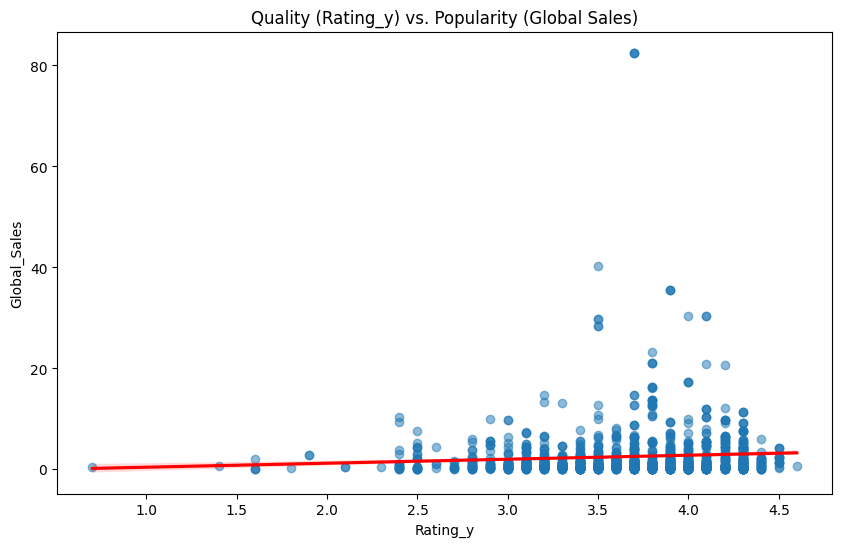

Correlation: 0.0733, P-value: 5.9292e-03


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df_sales = pd.read_csv('vgsales.csv.zip')
df_popular = pd.read_csv('games.csv.zip')

df_sales['Name_Clean'] = df_sales['Name'].astype(str).str.lower().str.strip()
df_popular['Title_Clean'] = df_popular['Title'].astype(str).str.lower().str.strip()
df_merged = pd.merge(df_sales, df_popular, left_on='Name_Clean', right_on='Title_Clean', how='inner')
print("Columns after merge:", df_merged.columns.tolist())
target_col = None
for col in ['Rating', 'Rating_y', 'Rating_x']:
    if col in df_merged.columns:
        target_col = col
        break

if target_col is None:
    print("Error: Could not find a Rating column after merge!")

else:
    df_merged[target_col] = pd.to_numeric(df_merged[target_col], errors='coerce')
    df_merged['Global_Sales'] = pd.to_numeric(df_merged['Global_Sales'], errors='coerce')
    df_merged = df_merged.dropna(subset=['Global_Sales', target_col])
    print(f"Success! Using column '{target_col}'. Matched {len(df_merged)} games.")
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_merged, x=target_col, y='Global_Sales', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'Quality ({target_col}) vs. Popularity (Global Sales)')
    plt.show()
    corr, p = pearsonr(df_merged[target_col], df_merged['Global_Sales'])
    print(f"Correlation: {corr:.4f}, P-value: {p:.4e}")

This Graph shows the correlation between the quality of a game and its rating.